In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import seaborn as sns
import nltk

In [ ]:
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from nltk.tokenize import RegexpTokenizer
from sklearn import metrics

In [ ]:
dataset_path = "/content/drive/MyDrive/Tanmoy_Khan_Akash - (B.Sc_Final_Year_Thesis)/Datasets - Phishing URL/Dataset/phishing_dataset.csv"
encoding = "ISO-8859-1"

In [ ]:
df = pd.read_csv(dataset_path, encoding=encoding)
df

,URL,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_and,nb_underscore,nb_percent,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,dns_record,google_index,page_rank,label
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,0,1,0,45,-1,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,0,1,0,0,77,5767,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,2,2,0,...,0,1,0,0,14,4004,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,0,1,0,0,62,-1,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,0,1,0,224,8175,0,0,6,legitimate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11425,http://www.fontspace.com/category/blackletter,45,17,0,2,0,0,0,0,0,...,0,0,0,0,448,5396,0,0,6,legitimate
11426,http://www.budgetbots.com/server.php/Server%20...,84,18,0,5,0,1,0,0,1,...,0,1,0,0,211,6728,0,1,0,phishing
11427,https://www.facebook.com/Interactive-Televisio...,105,16,1,2,6,0,0,1,0,...,0,0,0,0,2809,8515,0,1,10,legitimate
11428,http://www.mypublicdomainpictures.com/,38,30,0,2,0,0,0,0,0,...,0,1,0,0,85,2836,0,0,4,legitimate


In [ ]:
df.shape

(11430, 56)

**There is Imbalance in the data**

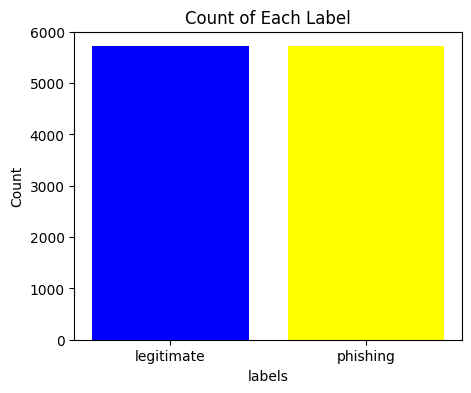

In [ ]:
label_counts = df['label'].value_counts()

plt.figure(figsize=(5, 4))
plt.bar(label_counts.index, label_counts.values, color=['blue', 'yellow'])
plt.xlabel('labels')
plt.ylabel('Count')
plt.title('Count of Each Label')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 56 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   URL                         11430 non-null  object 
 1   length_url                  11430 non-null  int64  
 2   length_hostname             11430 non-null  int64  
 3   ip                          11430 non-null  int64  
 4   nb_dots                     11430 non-null  int64  
 5   nb_hyphens                  11430 non-null  int64  
 6   nb_at                       11430 non-null  int64  
 7   nb_and                      11430 non-null  int64  
 8   nb_underscore               11430 non-null  int64  
 9   nb_percent                  11430 non-null  int64  
 10  nb_slash                    11430 non-null  int64  
 11  nb_colon                    11430 non-null  int64  
 12  nb_comma                    11430 non-null  int64  
 13  nb_semicolumn               114

**There is no nulls in the dataset**

In [ ]:
df.isna().sum()

URL                           0
length_url                    0
length_hostname               0
ip                            0
nb_dots                       0
nb_hyphens                    0
nb_at                         0
nb_and                        0
nb_underscore                 0
nb_percent                    0
nb_slash                      0
nb_colon                      0
nb_comma                      0
nb_semicolumn                 0
nb_dollar                     0
nb_space                      0
nb_www                        0
nb_com                        0
http_in_path                  0
https_token                   0
ratio_digits_url              0
ratio_digits_host             0
port                          0
nb_subdomains                 0
prefix_suffix                 0
random_domain                 0
length_words_raw              0
char_repeat                   0
shortest_words_raw            0
shortest_word_host            0
shortest_word_path            0
longest_

**Check and remove duplicates**

In [ ]:
df.URL.duplicated().sum()

1

In [ ]:
df.drop(df[df.URL.duplicated() == True].index, axis = 0, inplace = True)
df.reset_index(drop=True)

,URL,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_and,nb_underscore,nb_percent,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,dns_record,google_index,page_rank,label
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,0,1,0,45,-1,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,0,1,0,0,77,5767,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,2,2,0,...,0,1,0,0,14,4004,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,0,1,0,0,62,-1,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,0,1,0,224,8175,0,0,6,legitimate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11424,http://www.fontspace.com/category/blackletter,45,17,0,2,0,0,0,0,0,...,0,0,0,0,448,5396,0,0,6,legitimate
11425,http://www.budgetbots.com/server.php/Server%20...,84,18,0,5,0,1,0,0,1,...,0,1,0,0,211,6728,0,1,0,phishing
11426,https://www.facebook.com/Interactive-Televisio...,105,16,1,2,6,0,0,1,0,...,0,0,0,0,2809,8515,0,1,10,legitimate
11427,http://www.mypublicdomainpictures.com/,38,30,0,2,0,0,0,0,0,...,0,1,0,0,85,2836,0,0,4,legitimate


**Heatmap graph**

<ipython-input-12-cf519fd866da>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df.corr()
<ipython-input-12-cf519fd866da>:3: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask = np.triu(np.ones_like(corr, dtype=np.bool))


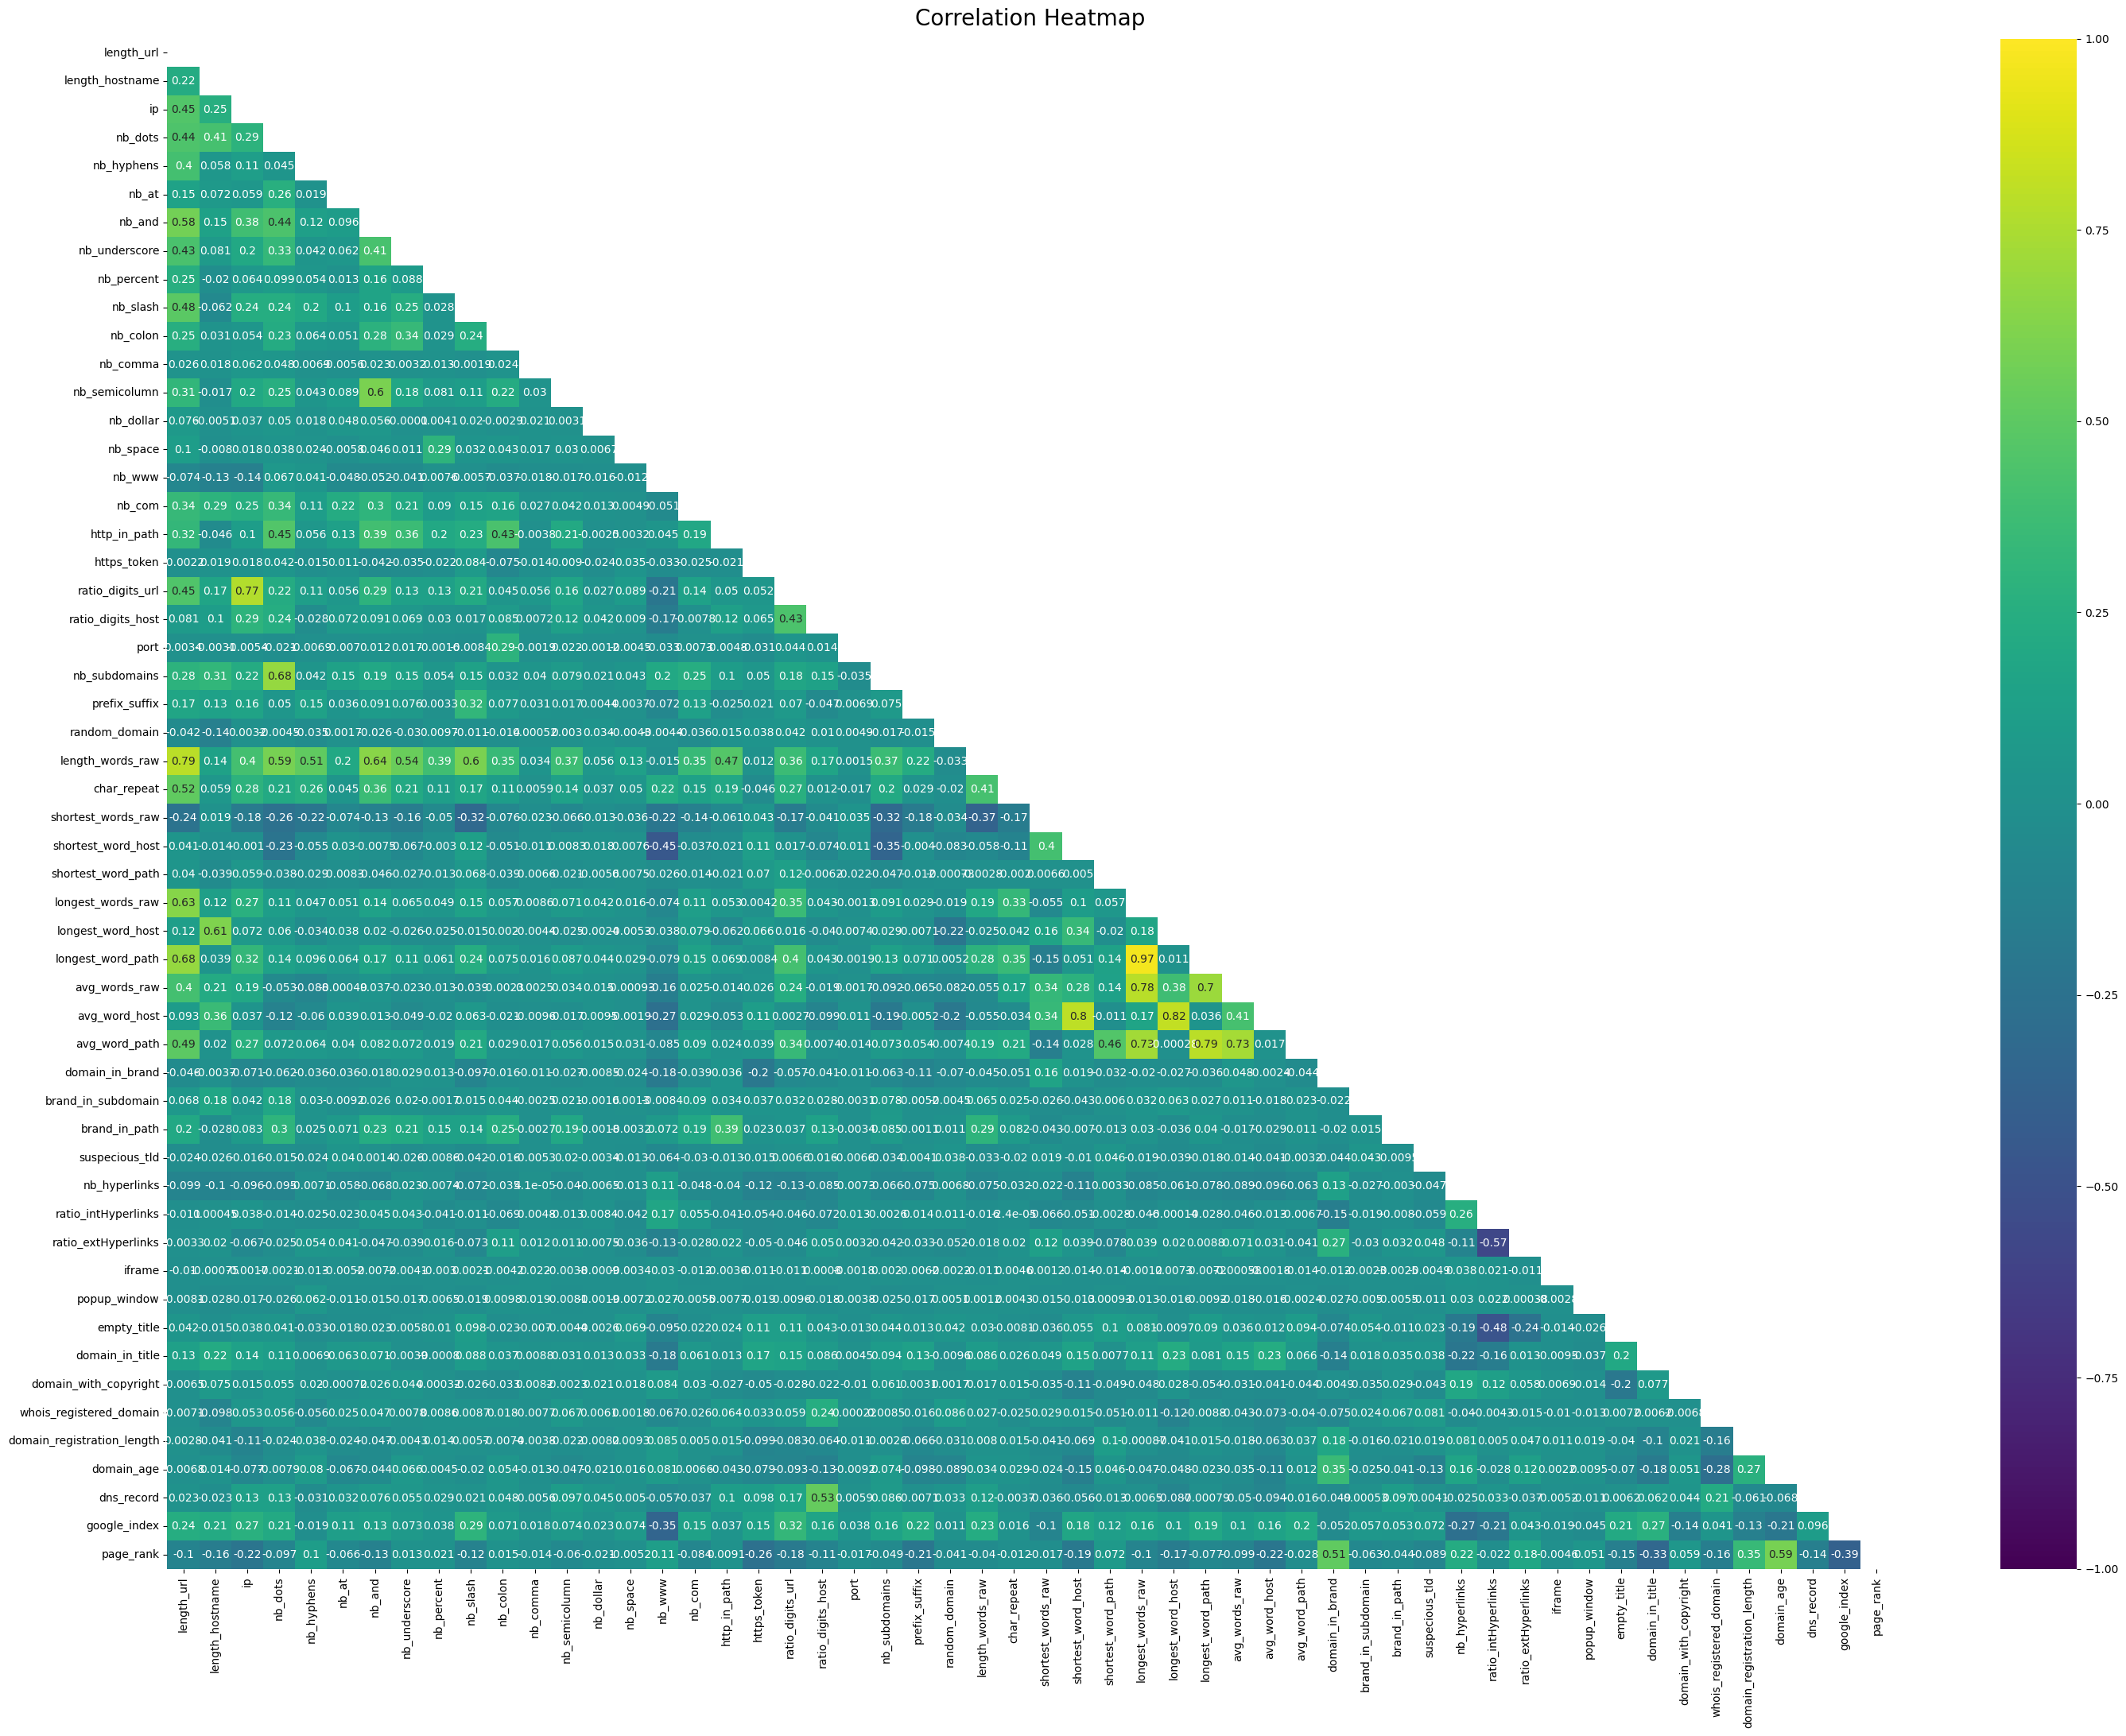

In [ ]:
plt.figure(figsize=(35, 25))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=np.bool))
heatmap = sns.heatmap(corr, mask=mask, vmin=-1, vmax=1, annot=True, cmap='viridis')
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize': 20}, pad=12)
plt.savefig('heatmap.png', dpi=300, bbox_inches='tight')

plt.show()

**Handling StopWords**

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords

print(stopwords.words('english'))
sw = list(set(stopwords.words("english")))

['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', '

In [ ]:
df['fresh_url']=df.URL.astype(str)

df.head()

,URL,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_and,nb_underscore,nb_percent,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,dns_record,google_index,page_rank,label,fresh_url
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,1,1,4,legitimate,http://www.crestonwood.com/router.php
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,1,2,phishing,http://shadetreetechnology.com/V4/validation/a...
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,2,2,0,...,1,0,0,14,4004,0,1,0,phishing,https://support-appleld.com.secureupdate.duila...
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,0,0,3,legitimate,http://rgipt.ac.in
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,0,0,6,legitimate,http://www.iracing.com/tracks/gateway-motorspo...


In [ ]:
df.URL.duplicated().sum()

0

**Take only the Alphabets**

In [ ]:
tok= RegexpTokenizer(r'[A-Za-z0-9]+')
tok.tokenize(df.URL[1])

['http',
 'shadetreetechnology',
 'com',
 'V4',
 'validation',
 'a111aedc8ae390eabcfa130e041a10a4']

In [ ]:
df.fresh_url=df.fresh_url.map(lambda x: tok.tokenize(x))

In [ ]:
df.head()

,URL,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_and,nb_underscore,nb_percent,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,dns_record,google_index,page_rank,label,fresh_url
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,1,1,4,legitimate,"[http, www, crestonwood, com, router, php]"
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,1,2,phishing,"[http, shadetreetechnology, com, V4, validatio..."
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,2,2,0,...,1,0,0,14,4004,0,1,0,phishing,"[https, support, appleld, com, secureupdate, d..."
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,0,0,3,legitimate,"[http, rgipt, ac, in]"
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,0,0,6,legitimate,"[http, www, iracing, com, tracks, gateway, mot..."


**Word Lemmtization**

In [ ]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

wnl = WordNetLemmatizer()
df['lem_url'] = df['fresh_url'].map(lambda x: [wnl.lemmatize(word) for word in x])
df.head()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


,URL,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_and,nb_underscore,nb_percent,...,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,dns_record,google_index,page_rank,label,fresh_url,lem_url
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,1,0,45,-1,1,1,4,legitimate,"[http, www, crestonwood, com, router, php]","[http, www, crestonwood, com, router, php]"
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,0,0,77,5767,0,1,2,phishing,"[http, shadetreetechnology, com, V4, validatio...","[http, shadetreetechnology, com, V4, validatio..."
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,2,2,0,...,0,0,14,4004,0,1,0,phishing,"[https, support, appleld, com, secureupdate, d...","[http, support, appleld, com, secureupdate, du..."
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,0,0,62,-1,0,0,3,legitimate,"[http, rgipt, ac, in]","[http, rgipt, ac, in]"
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,1,0,224,8175,0,0,6,legitimate,"[http, www, iracing, com, tracks, gateway, mot...","[http, www, iracing, com, track, gateway, moto..."


In [ ]:
df.isna().sum()

URL                           0
length_url                    0
length_hostname               0
ip                            0
nb_dots                       0
nb_hyphens                    0
nb_at                         0
nb_and                        0
nb_underscore                 0
nb_percent                    0
nb_slash                      0
nb_colon                      0
nb_comma                      0
nb_semicolumn                 0
nb_dollar                     0
nb_space                      0
nb_www                        0
nb_com                        0
http_in_path                  0
https_token                   0
ratio_digits_url              0
ratio_digits_host             0
port                          0
nb_subdomains                 0
prefix_suffix                 0
random_domain                 0
length_words_raw              0
char_repeat                   0
shortest_words_raw            0
shortest_word_host            0
shortest_word_path            0
longest_

**Vectorizing using TF-IDF**

In [ ]:
word_vectorizer = TfidfVectorizer(ngram_range=(1,1), max_features =1000)

unigramdataGet= word_vectorizer.fit_transform(df['lem_url'].astype('str'))
unigramdataGet = unigramdataGet.toarray()
vocab = word_vectorizer.get_feature_names_out ()
x=pd.DataFrame(np.round(unigramdataGet, 1), columns=vocab)
x[x>0] = 1

In [ ]:
x

,0000,000000000000,00000003,000webhostapp,007acctpagetype,01,02,03,04,05,...,yahoo,yahooverification,yolasite,you,your,yourdictionary,youtube,yyy,za,zo
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11424,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11425,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11426,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11427,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Vectorizing CountVectorizer**

In [ ]:
cv = CountVectorizer()
feature = cv.fit_transform(df.lem_url.astype('str'))
feature

<11429x20108 sparse matrix of type '<class 'numpy.int64'>'
	with 88343 stored elements in Compressed Sparse Row format>

**It seems that count vec act better**

In [ ]:
y=df.label
y=np.where(y=='phishing',0,1)

x_train,x_test,y_train,y_test = train_test_split(feature,y,random_state=42,test_size=0.2,shuffle=True)

**Our New Proposed Model**

In [ ]:
!pip install tensorflow

**For Linear Kernel**

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Define custom activation function for linear kernel
def linear_kernel_activation(x):
    return x

# Generate data using make_classification
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X = StandardScaler().fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a neural network model with linear kernel
model_linear_kernel = keras.Sequential([
    keras.layers.Dense(64, input_shape=(X_train.shape[1],), activation=linear_kernel_activation),  # Linear Kernel Activation
    keras.layers.Dense(1, activation='sigmoid')  # Output layer
])

# Compile the model
model_linear_kernel.compile(optimizer='adam',
                            loss='binary_crossentropy',
                            metrics=['accuracy'])

# Train the model
model_linear_kernel.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

# Make predictions on the test data
y_pred_linear_kernel = model_linear_kernel.predict(X_test)
y_pred_binary_linear_kernel = (y_pred_linear_kernel > 0.5).astype(int)

# Calculate accuracy
accuracy_linear_kernel = accuracy_score(y_test, y_pred_binary_linear_kernel)
print(f"Linear Kernel Accuracy: {accuracy_linear_kernel}")


Epoch 1/10
25/25 [==============================] - 2s 2ms/step - loss: 0.6256 - accuracy: 0.6550
Epoch 2/10
25/25 [==============================] - 0s 3ms/step - loss: 0.4476 - accuracy: 0.8475
Epoch 3/10
25/25 [==============================] - 0s 3ms/step - loss: 0.3846 - accuracy: 0.8712
Epoch 4/10
25/25 [==============================] - 0s 2ms/step - loss: 0.3541 - accuracy: 0.8750
Epoch 5/10
25/25 [==============================] - 0s 2ms/step - loss: 0.3401 - accuracy: 0.8737
Epoch 6/10
25/25 [==============================] - 0s 4ms/step - loss: 0.3321 - accuracy: 0.8700
Epoch 7/10
25/25 [==============================] - 0s 2ms/step - loss: 0.3279 - accuracy: 0.8763
Epoch 8/10
25/25 [==============================] - 0s 2ms/step - loss: 0.3244 - accuracy: 0.8775
Epoch 9/10
25/25 [==============================] - 0s 2ms/step - loss: 0.3236 - accuracy: 0.8788
Epoch 10/10
7/7 [==============================] - 0s 3ms/step
Linear Kernel Accuracy: 0.865


In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(y_test,y_pred_binary_linear_kernel))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86        93
           1       0.93      0.81      0.87       107

    accuracy                           0.86       200
   macro avg       0.87      0.87      0.86       200
weighted avg       0.87      0.86      0.87       200



**For RBF Kernel**

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Define custom activation function for RBF kernel
def rbf_kernel_activation(x):
    gamma = 1.0  # Adjust this parameter
    return tf.exp(-gamma * tf.square(x))

# Generate data using make_classification
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X = StandardScaler().fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a neural network model with RBF kernel
model_rbf_kernel = keras.Sequential([
    keras.layers.Dense(64, input_shape=(X_train.shape[1],), activation=rbf_kernel_activation),  # RBF Kernel Activation
    keras.layers.Dense(1, activation='sigmoid')  # Output layer
])

# Compile the model
model_rbf_kernel.compile(optimizer='adam',
                         loss='binary_crossentropy',
                         metrics=['accuracy'])

# Train the model
model_rbf_kernel.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

# Make predictions on the test data
y_pred_rbf_kernel = model_rbf_kernel.predict(X_test)
y_pred_binary_rbf_kernel = (y_pred_rbf_kernel > 0.5).astype(int)

# Calculate accuracy
accuracy_rbf_kernel = accuracy_score(y_test, y_pred_binary_rbf_kernel)
print(f"RBF Kernel Accuracy: {accuracy_rbf_kernel}")


Epoch 1/10
25/25 [==============================] - 0s 1ms/step - loss: 0.7095 - accuracy: 0.4950
Epoch 2/10
25/25 [==============================] - 0s 1ms/step - loss: 0.6841 - accuracy: 0.5550
Epoch 3/10
25/25 [==============================] - 0s 1ms/step - loss: 0.6645 - accuracy: 0.6050
Epoch 4/10
25/25 [==============================] - 0s 1ms/step - loss: 0.6426 - accuracy: 0.6575
Epoch 5/10
25/25 [==============================] - 0s 1ms/step - loss: 0.6218 - accuracy: 0.6913
Epoch 6/10
25/25 [==============================] - 0s 2ms/step - loss: 0.6008 - accuracy: 0.7262
Epoch 7/10
25/25 [==============================] - 0s 3ms/step - loss: 0.5769 - accuracy: 0.7650
Epoch 8/10
25/25 [==============================] - 0s 2ms/step - loss: 0.5513 - accuracy: 0.7950
Epoch 9/10
25/25 [==============================] - 0s 3ms/step - loss: 0.5245 - accuracy: 0.8325
Epoch 10/10
7/7 [==============================] - 0s 2ms/step
RBF Kernel Accuracy: 0.765


In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(y_test,y_pred_binary_rbf_kernel))

              precision    recall  f1-score   support

           0       0.74      0.88      0.80        93
           1       0.88      0.73      0.80       107

    accuracy                           0.80       200
   macro avg       0.81      0.81      0.80       200
weighted avg       0.81      0.80      0.80       200



**For Polynomial**

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Define custom activation function for polynomial kernel
def polynomial_kernel_activation(x):
    degree = 3  # Adjust this parameter
    return tf.pow((1 + x), degree)

# Generate data using make_classification
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X = StandardScaler().fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a neural network model with polynomial kernel
model_polynomial_kernel = keras.Sequential([
    keras.layers.Dense(64, input_shape=(X_train.shape[1],), activation=polynomial_kernel_activation),  # Polynomial Kernel Activation
    keras.layers.Dense(1, activation='sigmoid')  # Output layer
])

# Compile the model
model_polynomial_kernel.compile(optimizer='adam',
                                loss='binary_crossentropy',
                                metrics=['accuracy'])

# Train the model
model_polynomial_kernel.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

# Make predictions on the test data
y_pred_polynomial_kernel = model_polynomial_kernel.predict(X_test)
y_pred_binary_polynomial_kernel = (y_pred_polynomial_kernel > 0.5).astype(int)

# Calculate accuracy
accuracy_polynomial_kernel = accuracy_score(y_test, y_pred_binary_polynomial_kernel)
print(f"Polynomial Kernel Accuracy: {accuracy_polynomial_kernel}")


Epoch 1/10
25/25 [==============================] - 0s 1ms/step - loss: 1.0743 - accuracy: 0.7038
Epoch 2/10
25/25 [==============================] - 0s 1ms/step - loss: 0.6319 - accuracy: 0.8075
Epoch 3/10
25/25 [==============================] - 0s 1ms/step - loss: 0.5190 - accuracy: 0.8275
Epoch 4/10
25/25 [==============================] - 0s 1ms/step - loss: 0.4591 - accuracy: 0.8363
Epoch 5/10
25/25 [==============================] - 0s 1ms/step - loss: 0.4165 - accuracy: 0.8462
Epoch 6/10
25/25 [==============================] - 0s 1ms/step - loss: 0.3794 - accuracy: 0.8550
Epoch 7/10
25/25 [==============================] - 0s 1ms/step - loss: 0.3486 - accuracy: 0.8612
Epoch 8/10
25/25 [==============================] - 0s 1ms/step - loss: 0.3232 - accuracy: 0.8687
Epoch 9/10
25/25 [==============================] - 0s 1ms/step - loss: 0.3019 - accuracy: 0.8875
Epoch 10/10
7/7 [==============================] - 0s 1ms/step
Polynomial Kernel Accuracy: 0.825


In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(y_test,y_pred_binary_polynomial_kernel))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85        93
           1       0.88      0.86      0.87       107

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200



**For Sigmoid Kernel**

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Define custom activation function for sigmoid kernel
def sigmoid_kernel_activation(x):
    return tf.keras.activations.sigmoid(x)

# Generate data using make_classification
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X = StandardScaler().fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a neural network model with sigmoid kernel
model_sigmoid_kernel = keras.Sequential([
    keras.layers.Dense(64, input_shape=(X_train.shape[1],), activation=sigmoid_kernel_activation),  # Sigmoid Kernel Activation
    keras.layers.Dense(1, activation='sigmoid')  # Output layer
])

# Compile the model
model_sigmoid_kernel.compile(optimizer='adam',
                             loss='binary_crossentropy',
                             metrics=['accuracy'])

# Train the model
model_sigmoid_kernel.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

# Make predictions on the test data
y_pred_sigmoid_kernel = model_sigmoid_kernel.predict(X_test)
y_pred_binary_sigmoid_kernel = (y_pred_sigmoid_kernel > 0.5).astype(int)

# Calculate accuracy
accuracy_sigmoid_kernel = accuracy_score(y_test, y_pred_binary_sigmoid_kernel)
print(f"Sigmoid Kernel Accuracy: {accuracy_sigmoid_kernel}")


Epoch 1/10
25/25 [==============================] - 0s 1ms/step - loss: 0.6478 - accuracy: 0.6687
Epoch 2/10
25/25 [==============================] - 0s 2ms/step - loss: 0.5969 - accuracy: 0.7688
Epoch 3/10
25/25 [==============================] - 0s 1ms/step - loss: 0.5545 - accuracy: 0.8150
Epoch 4/10
25/25 [==============================] - 0s 1ms/step - loss: 0.5178 - accuracy: 0.8288
Epoch 5/10
25/25 [==============================] - 0s 1ms/step - loss: 0.4852 - accuracy: 0.8363
Epoch 6/10
25/25 [==============================] - 0s 1ms/step - loss: 0.4558 - accuracy: 0.8587
Epoch 7/10
25/25 [==============================] - 0s 1ms/step - loss: 0.4320 - accuracy: 0.8662
Epoch 8/10
25/25 [==============================] - 0s 1ms/step - loss: 0.4111 - accuracy: 0.8700
Epoch 9/10
25/25 [==============================] - 0s 1ms/step - loss: 0.3938 - accuracy: 0.8763
Epoch 10/10
7/7 [==============================] - 0s 1ms/step
Sigmoid Kernel Accuracy: 0.845


In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(y_test,y_pred_binary_sigmoid_kernel))

              precision    recall  f1-score   support

           0       0.78      0.94      0.85        93
           1       0.93      0.78      0.85       107

    accuracy                           0.85       200
   macro avg       0.86      0.86      0.85       200
weighted avg       0.86      0.85      0.85       200



**In the provided code, I have created four neural network models, each using a different custom activation function (Linear, RBF, Polynomial & Sigmoid Kernels) = Hybrid Model.**

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Define custom activation function for linear kernel
def linear_kernel_activation(x):
    return x

# Define custom activation function for RBF kernel
def rbf_kernel_activation(x):
    gamma = 1.0  # Adjust this parameter
    return tf.exp(-gamma * tf.square(x))

# Define custom activation function for polynomial kernel
def polynomial_kernel_activation(x):
    degree = 3  # Adjust this parameter
    return tf.pow((1 + x), degree)

# Define custom activation function for sigmoid kernel
def sigmoid_kernel_activation(x):
    return tf.keras.activations.sigmoid(x)

# Generate data using make_classification
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X = StandardScaler().fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a neural network model with multiple kernel functions
model = keras.Sequential([
    keras.layers.Dense(64, input_shape=(X_train.shape[1],), activation=linear_kernel_activation),  # Linear Kernel Activation
    keras.layers.Dense(64, activation=rbf_kernel_activation),  # RBF Kernel Activation
    keras.layers.Dense(64, activation=polynomial_kernel_activation),  # Polynomial Kernel Activation
    keras.layers.Dense(64, activation=sigmoid_kernel_activation),  # Sigmoid Kernel Activation
    keras.layers.Dense(1, activation='sigmoid')  # Output layer
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

# Make predictions on the test data
y_pred = model.predict(X_test)
y_pred_binary = (y_pred > 0.5).astype(int)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Accuracy: {accuracy}")


Epoch 1/10
25/25 [==============================] - 1s 2ms/step - loss: 0.7039 - accuracy: 0.5400
Epoch 2/10
25/25 [==============================] - 0s 2ms/step - loss: 0.6674 - accuracy: 0.5888
Epoch 3/10
25/25 [==============================] - 0s 2ms/step - loss: 0.6230 - accuracy: 0.6587
Epoch 4/10
25/25 [==============================] - 0s 2ms/step - loss: 0.5209 - accuracy: 0.7600
Epoch 5/10
25/25 [==============================] - 0s 2ms/step - loss: 0.3753 - accuracy: 0.8662
Epoch 6/10
25/25 [==============================] - 0s 2ms/step - loss: 0.2693 - accuracy: 0.9013
Epoch 7/10
25/25 [==============================] - 0s 2ms/step - loss: 0.2134 - accuracy: 0.9187
Epoch 8/10
25/25 [==============================] - 0s 2ms/step - loss: 0.1827 - accuracy: 0.9413
Epoch 9/10
25/25 [==============================] - 0s 2ms/step - loss: 0.1394 - accuracy: 0.9513
Epoch 10/10
7/7 [==============================] - 0s 2ms/step
Accuracy: 0.855


In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(y_test,y_pred_binary))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85        93
           1       0.89      0.83      0.86       107

    accuracy                           0.85       200
   macro avg       0.85      0.86      0.85       200
weighted avg       0.86      0.85      0.86       200

